##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install transformers scikit-learn pillow

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/122.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.9 MB ? eta -:--:--
    --------------------------------------- 1.6/122.9 MB 5.0 MB/s eta 0:00:25
   -- ------------------------------------- 6.8/122.9 MB 13.8 MB/s eta 0:00:09
   ---- ----------------------------------- 13.1/122.9 MB 18.5 MB/s eta 0:00:06
   ---- ----------------------------------- 13.9/122.9 MB 19.0 MB/s eta 0:00:06
   ------- -------------------------------- 24.4/122.9 MB 21.7 MB/s eta 0:00:05
   --------- ------------------------------ 30.4/122.9 MB 22.8 MB/s eta 0:00:05
   --------- ------------------------

In [14]:
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from transformers import AutoImageProcessor, AutoModel, AutoModelForImageClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
embedding_model_id = "facebook/dinov2-small"
classification_model_id = "facebook/dinov2-small-imagenet1k-1-layer"

embedding_processor = AutoImageProcessor.from_pretrained(embedding_model_id)
embedding_model = AutoModel.from_pretrained(embedding_model_id).to(device)
embedding_model.eval()

classification_processor = AutoImageProcessor.from_pretrained(classification_model_id)
classification_model = AutoModelForImageClassification.from_pretrained(classification_model_id).to(device)
classification_model.eval()

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 2246.82it/s]
c:\Users\A NWAR DAHAN\anaconda3\envs\cv_lab\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\A NWAR DAHAN\.cache\huggingface\hub\models--facebook--dinov2-small-imagenet1k-1-layer. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading 

Dinov2ForImageClassification(
  (dinov2): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True, bias=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1):

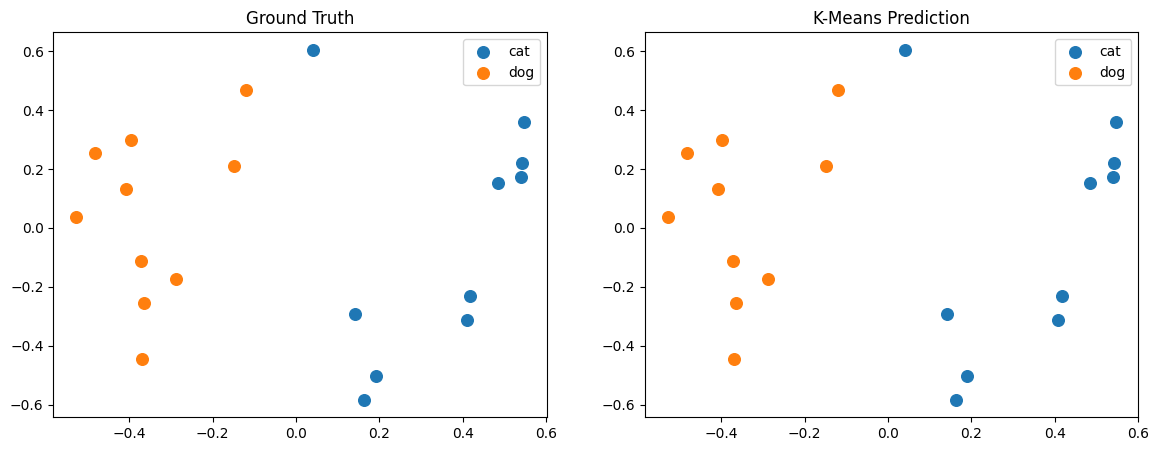

| raw_cluster | cats | dogs |
|---:|---:|---:|
| 0 | 0 | 10 |
| 1 | 10 | 0 |

| image | true_label | raw_cluster | predicted_label | correct |
|---|---|---:|---|---|
| British_Shorthair_144 | cat | 1 | cat | True |
| leonberger_18 | dog | 0 | dog | True |
| British_Shorthair_18 | cat | 1 | cat | True |
| yorkshire_terrier_139 | dog | 0 | dog | True |
| Birman_105 | cat | 1 | cat | True |
| scottish_terrier_102 | dog | 0 | dog | True |
| Siamese_119 | cat | 1 | cat | True |
| Maine_Coon_186 | cat | 1 | cat | True |
| basset_hound_154 | dog | 0 | dog | True |
| great_pyrenees_103 | dog | 0 | dog | True |
| Siamese_128 | cat | 1 | cat | True |
| pomeranian_152 | dog | 0 | dog | True |
| Birman_101 | cat | 1 | cat | True |
| Birman_110 | cat | 1 | cat | True |
| shiba_inu_160 | dog | 0 | dog | True |
| english_setter_151 | dog | 0 | dog | True |
| Ragdoll_181 | cat | 1 | cat | True |
| Bombay_175 | cat | 1 | cat | True |
| staffordshire_bull_terrier_117 | dog | 0 | dog | True |
| saint_bernard_11 | dog | 0 | dog | True |

Project root: C:\Users\A NWAR DAHAN\Downloads\lab10-visual-representations
Embedding matrix shape: (20, 384)
Best cluster-to-label mapping: {0: 'dog', 1: 'cat'}
Mapped accuracy: 100.0%
Adjusted Rand Index: 1.0000
Mistakes: None


In [19]:
from sklearn.metrics import adjusted_rand_score

candidate_roots = [
    Path.cwd(),
    Path.cwd() / "lab10-visual-representations",
    Path.cwd() / "Downloads" / "lab10-visual-representations",
    Path.home() / "Downloads" / "lab10-visual-representations",
]

project_root = next(
    (
        root
        for root in candidate_roots
        if (root / "annotations" / "annotations" / "trainval.txt").exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not find the dataset folder. Make sure the notebook is inside the lab10-visual-representations project or set project_root manually."
    )

annotations_file = project_root / "annotations" / "annotations" / "trainval.txt"
images_dir = project_root / "images" / "images"

records = []
with open(annotations_file, "r", encoding="utf-8") as f:
    for line in f:
        image_name, class_id, species, breed_id = line.strip().split()
        records.append(
            {
                "image": image_name,
                "species": int(species),
                "path": images_dir / f"{image_name}.jpg",
            }
        )

rng = np.random.default_rng(42)
cat_records = [record for record in records if record["species"] == 1]
dog_records = [record for record in records if record["species"] == 2]
cats = [cat_records[i] for i in rng.choice(len(cat_records), size=10, replace=False)]
dogs = [dog_records[i] for i in rng.choice(len(dog_records), size=10, replace=False)]
sample_records = cats + dogs
rng.shuffle(sample_records)

true_labels = ["cat" if record["species"] == 1 else "dog" for record in sample_records]
true_binary = np.array([0 if label == "cat" else 1 for label in true_labels])

def get_cls_embedding(path):
    image = Image.open(path).convert("RGB")
    inputs = embedding_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = embedding_model(**inputs)
    return F.normalize(outputs.last_hidden_state[:, 0], p=2, dim=1).squeeze(0).cpu().numpy()

embeddings = np.vstack([get_cls_embedding(record["path"]) for record in sample_records])
clusters = KMeans(n_clusters=2, n_init=20, random_state=42).fit_predict(embeddings)

candidate_mappings = [
    {0: "cat", 1: "dog"},
    {0: "dog", 1: "cat"},
]
scores = []
for mapping in candidate_mappings:
    predicted = [mapping[int(cluster)] for cluster in clusters]
    accuracy = np.mean([pred == true for pred, true in zip(predicted, true_labels)])
    scores.append((accuracy, predicted, mapping))

best_accuracy, predicted_labels, best_mapping = max(scores, key=lambda item: item[0])
correct_flags = [pred == true for pred, true in zip(predicted_labels, true_labels)]
ari = adjusted_rand_score(true_binary, clusters)

cluster_counts = np.zeros((2, 2), dtype=int)
for cluster, true_value in zip(clusters, true_binary):
    cluster_counts[int(cluster), int(true_value)] += 1

projection = PCA(n_components=2).fit_transform(embeddings)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color in [("cat", "tab:blue"), ("dog", "tab:orange")]:
    idx = [i for i, true in enumerate(true_labels) if true == label]
    axes[0].scatter(projection[idx, 0], projection[idx, 1], label=label, color=color, s=70)
axes[0].set_title("Ground Truth")
axes[0].legend()

for label, color in [("cat", "tab:blue"), ("dog", "tab:orange")]:
    idx = [i for i, pred in enumerate(predicted_labels) if pred == label]
    axes[1].scatter(projection[idx, 0], projection[idx, 1], label=label, color=color, s=70)
axes[1].set_title("K-Means Prediction")
axes[1].legend()
plt.show()

cluster_rows = [
    "| raw_cluster | cats | dogs |",
    "|---:|---:|---:|",
]
for cluster_id in range(2):
    cluster_rows.append(
        f"| {cluster_id} | {cluster_counts[cluster_id, 0]} | {cluster_counts[cluster_id, 1]} |"
    )
display(Markdown("\n".join(cluster_rows)))

rows = [
    "| image | true_label | raw_cluster | predicted_label | correct |",
    "|---|---|---:|---|---|",
]
for i, record in enumerate(sample_records):
    rows.append(
        f"| {record['image']} | {true_labels[i]} | {int(clusters[i])} | {predicted_labels[i]} | {correct_flags[i]} |"
    )
display(Markdown("\n".join(rows)))

mistakes = [sample_records[i]["image"] for i, flag in enumerate(correct_flags) if not flag]
print("Project root:", project_root)
print("Embedding matrix shape:", embeddings.shape)
print("Best cluster-to-label mapping:", best_mapping)
print(f"Mapped accuracy: {best_accuracy * 100:.1f}%")
print(f"Adjusted Rand Index: {ari:.4f}")
print("Mistakes:", mistakes if mistakes else "None")

| seed | mapped_accuracy | ari |
|---:|---:|---:|
| 0 | 65.0% | 0.0400 |
| 1 | 90.0% | 0.6208 |
| 2 | 65.0% | 0.0442 |
| 3 | 85.0% | 0.4643 |
| 4 | 95.0% | 0.7996 |
| 5 | 75.0% | 0.2088 |
| 6 | 100.0% | 1.0000 |
| 7 | 75.0% | 0.2088 |
| 8 | 90.0% | 0.6200 |
| 9 | 90.0% | 0.6208 |

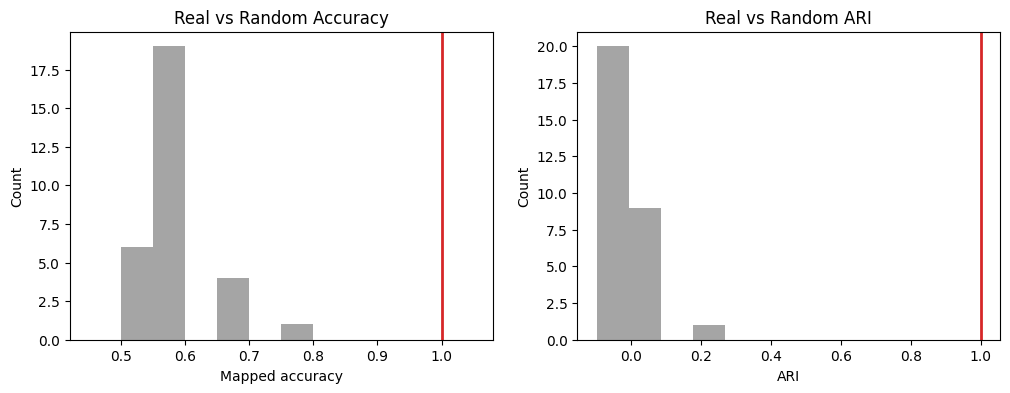

Current sample mapped accuracy: 100.0%
Current sample ARI: 1.0000
Random baseline mean mapped accuracy: 57.3%
Random baseline mean ARI: -0.0099
10-trial mean mapped accuracy: 83.0%
10-trial mean ARI: 0.4627


In [20]:
def clustering_scores(embeddings, true_binary):
    clusters = KMeans(n_clusters=2, n_init=20, random_state=42).fit_predict(embeddings)
    mapped_accuracy = max(np.mean(clusters == true_binary), np.mean((1 - clusters) == true_binary))
    ari_score = adjusted_rand_score(true_binary, clusters)
    return mapped_accuracy, ari_score

embedding_cache = {}

def get_cached_embedding(path):
    key = str(path)
    if key not in embedding_cache:
        embedding_cache[key] = get_cls_embedding(path)
    return embedding_cache[key]

real_acc, real_ari = clustering_scores(embeddings, true_binary)

random_accs = []
random_aris = []
for seed in range(30):
    rng_local = np.random.default_rng(seed)
    random_embeddings = rng_local.normal(size=embeddings.shape)
    acc, ari_score = clustering_scores(random_embeddings, true_binary)
    random_accs.append(acc)
    random_aris.append(ari_score)

trial_rows = [
    "| seed | mapped_accuracy | ari |",
    "|---:|---:|---:|",
]
trial_accs = []
trial_aris = []
for seed in range(10):
    rng_local = np.random.default_rng(100 + seed)
    cats = [cat_records[i] for i in rng_local.choice(len(cat_records), size=10, replace=False)]
    dogs = [dog_records[i] for i in rng_local.choice(len(dog_records), size=10, replace=False)]
    trial_records = cats + dogs
    rng_local.shuffle(trial_records)
    trial_true_binary = np.array([0 if record["species"] == 1 else 1 for record in trial_records])
    trial_embeddings = np.vstack([get_cached_embedding(record["path"]) for record in trial_records])
    acc, ari_score = clustering_scores(trial_embeddings, trial_true_binary)
    trial_accs.append(acc)
    trial_aris.append(ari_score)
    trial_rows.append(f"| {seed} | {acc * 100:.1f}% | {ari_score:.4f} |")

display(Markdown("\n".join(trial_rows)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(random_accs, bins=np.linspace(0.45, 1.05, 13), color="tab:gray", alpha=0.7)
axes[0].axvline(real_acc, color="tab:red", linewidth=2)
axes[0].set_title("Real vs Random Accuracy")
axes[0].set_xlabel("Mapped accuracy")
axes[0].set_ylabel("Count")

axes[1].hist(random_aris, bins=np.linspace(-0.1, 1.0, 13), color="tab:gray", alpha=0.7)
axes[1].axvline(real_ari, color="tab:red", linewidth=2)
axes[1].set_title("Real vs Random ARI")
axes[1].set_xlabel("ARI")
axes[1].set_ylabel("Count")

plt.show()

print(f"Current sample mapped accuracy: {real_acc * 100:.1f}%")
print(f"Current sample ARI: {real_ari:.4f}")
print(f"Random baseline mean mapped accuracy: {np.mean(random_accs) * 100:.1f}%")
print(f"Random baseline mean ARI: {np.mean(random_aris):.4f}")
print(f"10-trial mean mapped accuracy: {np.mean(trial_accs) * 100:.1f}%")
print(f"10-trial mean ARI: {np.mean(trial_aris):.4f}")


K-Means achieved 100% accuracy on the current 20-image sample after matching the two clusters to the cat and dog labels, but this result does not mean the model is always perfect. Additional validation across 10 different random samples gave an average clustering accuracy of 83.0% and an average ARI of 0.4627, which shows that DINOv2 features generally separate cats and dogs well, but performance changes depending on the selected images. The perfect result in this run most likely happened because this specific subset was easier to separate due to clearer visual differences such as face shape, fur pattern, pose, and background.


### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

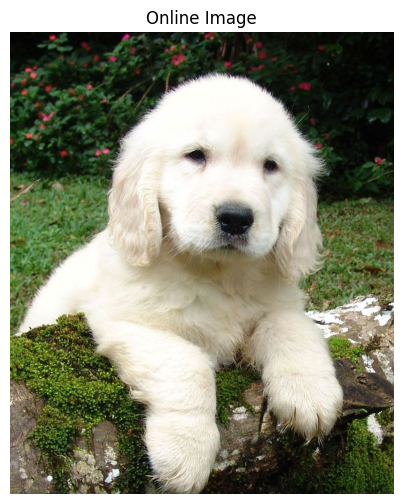

Image source: https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg


| rank | label | probability |
|---:|---|---:|
| 1 | golden retriever | 0.8519 |
| 2 | kuvasz | 0.0534 |
| 3 | cocker spaniel, English cocker spaniel, cocker | 0.0377 |
| 4 | clumber, clumber spaniel | 0.0121 |
| 5 | Labrador retriever | 0.0097 |

The model predicts **golden retriever** for this online image.

In [18]:
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

image_url = "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"
request = Request(image_url, headers={"User-Agent": "Mozilla/5.0"})

try:
    with urlopen(request, timeout=20) as response:
        image = Image.open(BytesIO(response.read())).convert("RGB")
except (HTTPError, URLError, TimeoutError) as error:
    raise RuntimeError(
        "Could not download the online image. Try another direct image URL from Wikimedia Commons or another public image host."
    ) from error

inputs = classification_processor(images=image, return_tensors="pt").to(device)
with torch.no_grad():
    logits = classification_model(**inputs).logits

probabilities = torch.softmax(logits, dim=-1)[0].cpu()
top_values, top_indices = torch.topk(probabilities, k=5)
predicted_label = classification_model.config.id2label[int(top_indices[0])]

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Online Image")
plt.show()

print("Image source:", image_url)

rows = [
    "| rank | label | probability |",
    "|---:|---|---:|",
]
for rank, (idx, value) in enumerate(zip(top_indices.tolist(), top_values.tolist()), start=1):
    label = classification_model.config.id2label[int(idx)]
    rows.append(f"| {rank} | {label} | {value:.4f} |")

display(Markdown("\n".join(rows)))
display(Markdown(f"The model predicts **{predicted_label}** for this online image."))
